<center>Universidade Federal de Viçosa</center>
<center>Coordenadoria de Educação Aberta e a Distância</center>
<center>Inteligência Artificial e Computacional</center>
<center>ELT578 - Análise de Imagens e Visão Computacional</center>

**<center>Desafio 5: Limiarização Global em Espaço RGB</center>**


In [ ]:
#Permissão para acessar o drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Importando bibliotecas
import cv2
import numpy as np
from skimage.io import imread, imshow
from scipy import stats
from matplotlib import pyplot as plt


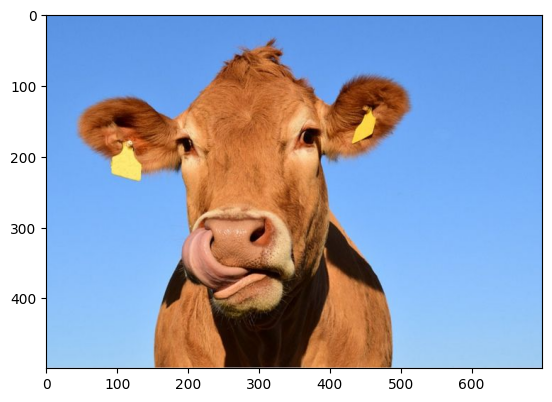

In [ ]:
#Lendo imagem
im = imread('/content/drive/MyDrive/ELT578/SEMANA_3/cow.jpg')
plt.imshow(im)

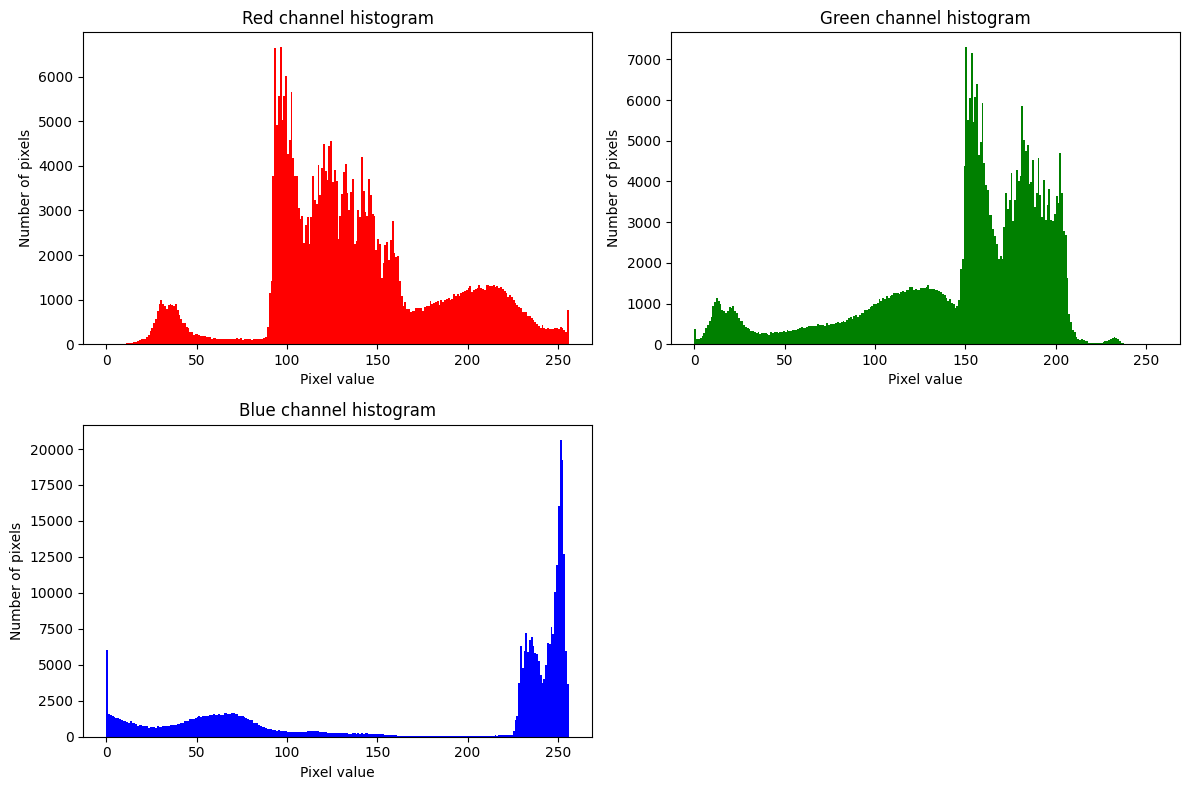

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
im_hist_red = plt.hist(im[:,:,0].flatten(), bins=256, range=[0, 256], facecolor='red')
plt.title('Red channel histogram')
plt.xlabel('Pixel value')
plt.ylabel('Number of pixels')
plt.subplot(2, 2, 2)
im_hist_green = plt.hist(im[:,:,1].flatten(), bins=256, range=[0, 256], facecolor='green')
plt.title('Green channel histogram')
plt.xlabel('Pixel value')
plt.ylabel('Number of pixels')
plt.subplot(2, 2, 3)
im_hist_blue = plt.hist(im[:,:,2].flatten(), bins=256, range=[0, 256], facecolor='blue')
plt.title('Blue channel histogram')
plt.xlabel('Pixel value')
plt.ylabel('Number of pixels')
plt.tight_layout()
plt.show()

In [ ]:
#Descritivas
max_pixel = np.max(np.max(im, axis=0), axis=0)
min_pixel = np.min(np.min(im, axis=0), axis=0)
mean_pixel = np.mean(np.mean(im, axis=0), axis=0)
median_pixel = np.median(np.median(im, axis=0), axis=0)
mode_pixel = stats.mode(stats.mode(im)[0].squeeze())[0].squeeze()

print(im.shape)

print(min_pixel)
print(max_pixel)
print(mean_pixel)
print(median_pixel)
print(mode_pixel)

(499, 700, 3)
[0 0 0]
[255 246 255]
[136.0762067  148.05388205 175.38623246]
[127. 175. 245.]
[ 93 150 252]


In [ ]:
#Ler cada banda separadamente
red = im[:,:,0]
green = im[:,:,1]
blue = im[:,:,2]

In [ ]:
#Definir os limites dos valores de px correspondente a vaca
#red_lower = 150
#red_upper = 255
#green_lower = 0
#green_upper = 160
blue_lower = 0
blue_upper = 200
#gray_upper = 250
#gray_lower = 255

In [ ]:
# Set to 0 all pixels that are outside the defined bounds for any channel
mask = (blue >= blue_lower) & (blue <= blue_upper)

#using all channels
#mask = (red >= red_lower) & (red <= red_upper) & \
#     (green >= green_lower) & (green <= green_upper) & \
#       (blue >= blue_lower) & (blue <= blue_upper)
rc = red.copy()
rc[np.invert(mask)] = 0
gc = green.copy()
gc[np.invert(mask)] = 0
bc = blue.copy()
bc[np.invert(mask)] = 0

# Recombine separate color channels into a single, true color RGB image
#using all channels
segmented_image = np.stack((rc, gc, bc), axis=-1)

segmented_image = np.stack((bc))


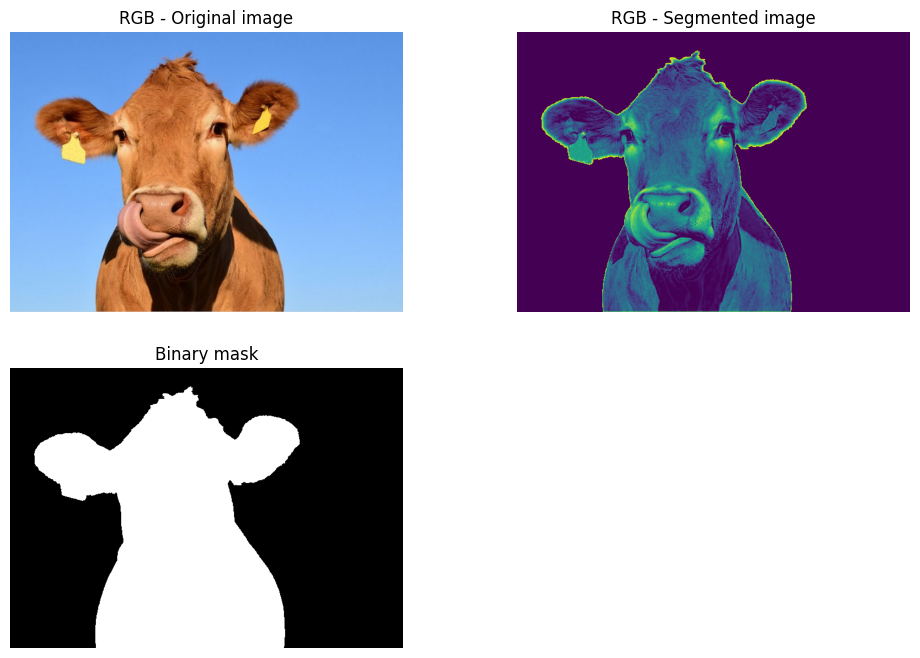

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.imshow(im)
plt.title('RGB - Original image')
plt.axis('off')
plt.subplot(2, 2, 2)
plt.imshow(segmented_image)
plt.title('RGB - Segmented image')
plt.axis('off')
plt.subplot(2, 2, 3)
plt.imshow(mask, cmap='gray')
plt.title('Binary mask')
plt.axis('off')
plt.show()

In [ ]:
from skimage import io
from skimage import img_as_uint

io.imsave('/content/drive/MyDrive/ELT578/SEMANA_3/cowbw.png', img_as_uint(mask)) #img_as_uint() é uma função da biblioteca scikit-image que converte a imagem para o formato de inteiro sem sinal de 16 bits (uint16).

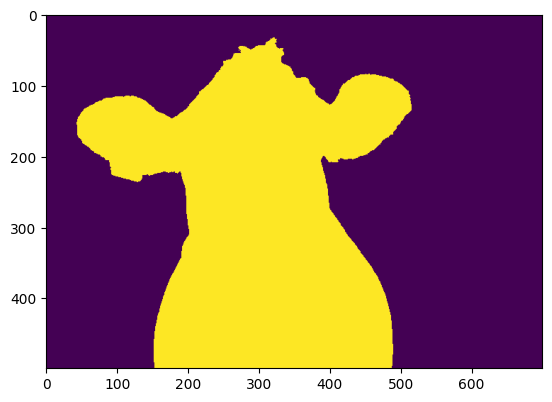

In [ ]:
binaryImage = imread(r'/content/drive/MyDrive/ELT578/SEMANA_3/cowbw.png')
Segim = plt.imshow(binaryImage)